# Riemannian PCA of heat-kernel tangent fields on a torus

Given a point cloud $\{y_i\}$ supported on a torus in $\mathbb{R}^3$ with weights $\mu_i$, this notebook

1. builds the averaged heat potential
   $u_\mu(x,t)=\sum_i \mu_i k_t(x,y_i)$ and the associated Fréchet functional
   $V(x,2t)=\tfrac{2}{C(2t)}-2u_\mu(x,2t)$, the $\mu$-average of the squared
   diffusion distance, so that **minimising $V$ = maximising $u_\mu$**;
2. locates the local minima (Fréchet means) of $V$ and picks a set of
   **reference points** in their near-minimal sublevel components;
3. uses the pointwise heat-kernel potential
   $u_t(x,y)=k_t(x,y)$ and stacks its reference-variable gradient
   $v_y(x)=\nabla_x k_t(x,y)$ over all reference points, centres the resulting
   fields, and diagonalises the $\mu$-weighted covariance $Q$ — **RiePCA**;

The notebook uses `riepca_euclidean.py`, a focused Euclidean-only implementation.





## 0. The RiePCA engines



In [1]:
# --- locate and import the RiePCA engine ---------------------------------
# Put riepca_euclidean.py next to this notebook. In Colab: the file pane on
# the left (it survives until the runtime is recycled), or keep it in Drive
# and mount it, which survives restarts.
import sys
from pathlib import Path

_candidates = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"),
               Path.cwd() / "upload", Path("/content/drive/MyDrive/riepca")]
_home = next((p for p in _candidates if (p / "riepca_euclidean.py").exists()), None)
if _home is None:
    raise FileNotFoundError(
        "riepca_euclidean.py not found. Upload it next to this notebook and "
        "rerun this cell. Searched: " + ", ".join(str(p) for p in _candidates))
if str(_home) not in sys.path:
    sys.path.insert(0, str(_home))

import numpy as np
import riepca_euclidean
from riepca_euclidean import (
    heat_gradient_fields, field_capacity, check_riepca,
    degenerate_blocks, block_magnitude, block_angle, block_summary,
    check_block_invariance,
    plot_eigenvalues, plot_variance_explained, plot_cumulative_variance,
    plot_spectrum_across_t, plot_block_magnitude,
)


def result_field_capacity(result):
    """r*d for a fitted result, under either riepca_euclidean revision.

    The attribute was renamed feature_capacity -> field_capacity; accept both
    so the notebook does not depend on which revision is installed.
    """
    for _name in ("field_capacity", "feature_capacity", "capacity"):
        if hasattr(result, _name):
            return int(getattr(result, _name))
    raise AttributeError("result carries no field-capacity attribute")


# NOTE: the `riepca` package also exports names such as EuclideanGeometry,
# RiePCAResult and check_riepca. The imports above bind the riepca_euclidean
# versions; if a later cell imports the package, write riepca_euclidean.X
# explicitly.
print("riepca_euclidean loaded from", _home / "riepca_euclidean.py")

riepca_euclidean loaded from /content/riepca_euclidean.py


In [2]:
from __future__ import annotations

import json
import os
import platform
import sys
from dataclasses import dataclass, asdict, field
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
from matplotlib.colors import Normalize, TwoSlopeNorm
from scipy.ndimage import generate_binary_structure, label, maximum_filter
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

TWO_PI = 2.0 * np.pi

# ---------------------------------------------------------------- figures
# One style block, applied once. Vector output by default: raster PNGs of 3-D
# scatter plots are what made the previous notebook 138 MB.
plt.style.use("default")
mpl.rcParams.update({
    "figure.facecolor":  "white",
    "savefig.facecolor": "white",
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
    #"font.family":       "serif",
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    12,
    "axes.grid":         True,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.6,
    "legend.frameon":    False,
    "legend.fontsize":   10,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "lines.linewidth":   1.6,
    "axes.prop_cycle":   mpl.cycler(color=[
        "#0F4C81", "#E4572E", "#17A398", "#8C4799", "#B8860B", "#5A5A5A"]),
})

ENV = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "sklearn": sklearn.__version__,
    "matplotlib": mpl.__version__,
}
print("\n".join(f"{k:12s} {v}" for k, v in ENV.items()))

python       3.13.15
platform     Linux-6.6.122+-x86_64-with-glibc2.35
numpy        2.1.3
scipy        1.16.3
sklearn      1.6.1
matplotlib   3.10.0


## 1. Configuration

Every tunable lives here. Nothing below reads a loose global.

In [3]:
@dataclass(frozen=True)
class Config:
    # --- data ---------------------------------------------------------
    seed: int = 40
    n_points: int = 2000
    R: float = 2.0            # major radius
    r: float = 0.8            # minor radius
    noise: float = 0.05       # isotropic ambient noise sd
    area_uniform: bool = False
    # False reproduces the original: theta, phi both uniform in [0, 2pi),
    # which oversamples the inner rim because dA = r(R + r cos phi) dphi dtheta.
    # True rejection-samples phi so the cloud is uniform on the SURFACE.
    # Report whichever you use -- it changes the density, hence u, hence the
    # Rips filtration.

    # --- heat times ---------------------------------------------------
    t_values: tuple = (0.01, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 1.0, 1.2, 1.3, 1.4, 1.5,
                       1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4.0, 5.0, 7.0, 8.0, 10.0, 12.0,
                       15.0, 17.0, 20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0)
    t_figures: tuple = (0.5, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4.0, 5.0)   # per-t figures only for these
    t_topology: tuple = (1.5, 2.0, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 5.0)
    t_reference: float = 0.01                 # t at which reference points are fixed

    # --- RiePCA -------------------------------------------------------
    top_k: int = 10
    n_pcs_topology: int = 4
    rel_eigen_floor: float = 1e-12
    degeneracy_ratio: float = 1.2

    # --- grids and reference points -----------------------------------
    pad: float = 0.2
    mode_grid: tuple = (20, 20, 20)
    ref_grid: tuple = (20, 20, 20)
    n_representatives: int = 25
    eps_quantile: float = 0.30   # band width as a fraction of the V range

    # --- persistent homology ------------------------------------------
    run_topology: bool = True
    ph_subsample: int | None = None  # None = 500 (slow: minutes to hours)
    ph_maxdim: int = 2
    ph_thresh_frac: float = 0.75     # ONE fraction, used for every metric.
    # 0.75 is the smallest cap at which the H1 and H2 signal classes of ALL
    # THREE metrics die before the cap; results are flat from here to 1.0.
    # At 0.60 the diffusion metric H1 is still pinned at infinity.
    ph_signal: tuple = (2, 1)        # expected rank of (H1, H2) for a torus

    # --- io -----------------------------------------------------------
    outdir: str = "figures"
    chunk: int = 4096

    @property
    def tag(self) -> str:
        return f"n{self.n_points}_R{self.R}_r{self.r}_noise{self.noise}"


CFG = Config()
OUT = Path(CFG.outdir) / CFG.tag
OUT.mkdir(parents=True, exist_ok=True)
(OUT / "config.json").write_text(json.dumps({**asdict(CFG), "env": ENV},
                                            indent=2, default=str))


def savefig(fig, name, formats=("pdf", "png")):
    """Save one figure under a unique stem, in vector and raster form."""
    for ext in formats:
        fig.savefig(OUT / f"{name}.{ext}")
    return OUT / f"{name}.pdf"


print(f"outputs -> {OUT.resolve()}")


outputs -> /content/figures/n2000_R2.0_r0.8_noise0.05


## 2. Angles, sampling, and the heat potential

`angular_mask` is the fix for the slice bug: `|theta - c| < tol` drops
everything on the far side of the $0/2\pi$ branch cut, so a slice centred at
$\theta = 0$ collects only its upper half.

In [4]:
def wrap_to_pi(a):
    """Wrap angles into [-pi, pi)."""
    return (np.asarray(a, float) + np.pi) % TWO_PI - np.pi


def angular_mask(angles, center, tol):
    """Points within `tol` of `center` ON THE CIRCLE.

    BUGFIX (B1). The naive |theta - center| < tol silently drops the half of
    the slice on the far side of the 0 / 2*pi branch cut. For this cloud a
    slice at theta = 0 with tol = 0.1 collects 35 points instead of 63.
    """
    return np.abs(wrap_to_pi(np.asarray(angles, float) - center)) < tol


def circular_corr(a, b):
    """Jammalamadaka circular-circular correlation coefficient."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    ma = np.angle(np.mean(np.exp(1j * a)))
    mb = np.angle(np.mean(np.exp(1j * b)))
    num = np.sum(np.sin(a - ma) * np.sin(b - mb))
    den = np.sqrt(np.sum(np.sin(a - ma) ** 2) * np.sum(np.sin(b - mb) ** 2))
    return float(num / den) if den > 0 else np.nan

def circ_assoc(a, b):
    """Association between two circular variables, invariant to rotation and
    to reflection, and well defined when both marginals are UNIFORM.

    circular_corr (Jammalamadaka) centres each variable on its circular mean.
    For theta ~ Uniform(0, 2pi) that mean does not exist -- the mean resultant
    length here is 0.004 to 0.04 -- so the coefficient centres on noise.

        |mean e^{i(a-b)}|   detects a rotation      (orientation preserved)
        |mean e^{i(a+b)}|   detects a reflection    (orientation reversed)

    1 = one angle determines the other, 0 = no association.
    """
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(max(abs(np.mean(np.exp(1j * (a - b)))),
                     abs(np.mean(np.exp(1j * (a + b))))))

def sample_torus(cfg, rng):
    """Torus point cloud with explicit control over the sampling measure.

    `rng` is a np.random.RandomState: RandomState(40) reproduces the draws of
    the original notebook's global np.random.seed(40) exactly, so the cloud is
    bit-identical to previously generated figures -- without global RNG state.
    """
    n, R, r = cfg.n_points, cfg.R, cfg.r
    theta = rng.uniform(0, TWO_PI, n)
    if cfg.area_uniform:
        phi, filled = np.empty(n), 0
        while filled < n:
            cand = rng.uniform(0, TWO_PI, n)
            keep = cand[rng.uniform(0, 1, n) < (R + r * np.cos(cand)) / (R + r)]
            take = min(len(keep), n - filled)
            phi[filled:filled + take] = keep[:take]
            filled += take
    else:
        phi = rng.uniform(0, TWO_PI, n)
    x = (R + r * np.cos(phi)) * np.cos(theta)
    y = (R + r * np.cos(phi)) * np.sin(theta)
    z = r * np.sin(phi)
    X = np.column_stack([x, y, z]) + cfg.noise * rng.randn(n, 3)
    return X, theta, phi

In [5]:
def u_at(points, data, mu, t, chunk=4096):
    """u(x,t) = sum_i mu_i k_t(x, y_i),  k_t = (4 pi t)^(-d/2) exp(-|x-y|^2/(4t)).

    Evaluated in log space and chunked over `points`, so a fine evaluation grid
    never materialises an (n_grid, n_data, d) difference array.
    """
    points = np.atleast_2d(np.asarray(points, float))
    d = points.shape[1]
    log_c = (-d / 2) * np.log(4 * np.pi * t)
    dn2 = np.einsum("ij,ij->i", data, data)
    out = np.empty(len(points))
    for s in range(0, len(points), chunk):
        P = points[s:s + chunk]
        dist2 = np.maximum(np.einsum("ij,ij->i", P, P)[:, None]
                           + dn2[None, :] - 2.0 * P @ data.T, 0.0)
        out[s:s + chunk] = np.exp(log_c - dist2 / (4 * t)) @ mu
    return out


def grad_u_at(x, data, mu, t):
    """grad_x u(x,t) = -(1/(2t)) sum_i mu_i k_t(x,y_i) (x - y_i)."""
    x = np.asarray(x, float)
    d = x.shape[0]
    diff = x[None, :] - data
    dist2 = np.einsum("ij,ij->i", diff, diff)
    k = np.exp((-d / 2) * np.log(4 * np.pi * t) - dist2 / (4 * t))
    return -(1.0 / (2.0 * t)) * ((mu * k)[:, None] * diff).sum(axis=0)


def V_from_u(u, t, d=3):
    """V(x,2t) = 2/C(2t) - 2 u(x,2t), with C(2t) = (4 pi (2t))^(d/2).

    This is the mu-average of the squared diffusion distance
    d_{2t}(x,y)^2 = k_{2t}(x,x) + k_{2t}(y,y) - 2 k_{2t}(x,y), using
    k_{2t}(x,x) = 1/C(2t). Minimising V is exactly maximising u.
    """
    return 2.0 / ((4 * np.pi * (2 * t)) ** (d / 2)) - 2.0 * u


def bbox_grid(data, pad, shape):
    lo, hi = data.min(0) - pad, data.max(0) + pad
    axes = [np.linspace(lo[i], hi[i], shape[i]) for i in range(len(shape))]
    mesh = np.meshgrid(*axes, indexing="ij")
    return axes, mesh, np.column_stack([m.ravel() for m in mesh])

## 3. Fréchet means

Local minima of $V(\cdot,2t)$ are local maxima of $u(\cdot,2t)$. Seeds come from
a coarse grid; each seed is then polished with L-BFGS-B on $-u$ using the
analytic gradient.

The previous version polished with 5 fixed steps of size $0.6$ along
$\nabla u$. Because $\nabla u$ carries a factor $(4\pi\cdot 2t)^{-d/2}/(4t)$,
that step is scale-blind: the measured seed-to-mode drift was $1.1\times10^{-1}$
at $t=0.01$ but $3\times10^{-4}$ at $t=1$ and $6\times10^{-8}$ at $t=50$. For
every $t\gtrsim 1$ the "refined" Fréchet mean was just the coarse grid vertex,
accurate only to the grid spacing ($\approx 0.3$ in $x,y$).

In [6]:
def frechet_modes(data, mu, t, cfg, all_local=True, verbose=False):
    """Local minima of V(.,2t). Returns a list sorted by decreasing u.

    BUGFIX (B2): seeds are polished with a real optimiser instead of a
    fixed-step ascent whose step size is meaningless across three decades of t.
    """
    axes, _, grid = bbox_grid(data, cfg.pad, cfg.mode_grid)
    u_vals = u_at(grid, data, mu, 2 * t, cfg.chunk)

    if all_local:
        u3 = u_vals.reshape(cfg.mode_grid)
        idx = np.argwhere(u3 == maximum_filter(u3, size=3))
        seeds = np.column_stack([axes[i][idx[:, i]] for i in range(3)])
    else:
        seeds = grid[np.argmax(u_vals)][None, :]

    neg_u = lambda x: -u_at(x[None, :], data, mu, 2 * t)[0]
    neg_g = lambda x: -grad_u_at(x, data, mu, 2 * t)

    modes, seen = [], []
    for s in seeds:
        res = minimize(neg_u, s, jac=neg_g, method="L-BFGS-B",
                       options=dict(maxiter=300, ftol=1e-18, gtol=1e-14))
        x = res.x
        if any(np.linalg.norm(x - p) < 1e-3 for p in seen):
            continue
        seen.append(x)
        u_star = float(u_at(x[None, :], data, mu, 2 * t)[0])
        modes.append(dict(x_star=tuple(map(float, x)),
                          u_max=u_star,
                          V_min=float(V_from_u(u_star, t, data.shape[1])),
                          seed_drift=float(np.linalg.norm(x - s)),
                          converged=bool(res.success)))
    modes.sort(key=lambda m: -m["u_max"])
    if verbose:
        drift = np.array([m["seed_drift"] for m in modes])
        print(f"  t={t:<6g} {len(seeds):3d} seeds -> {len(modes):3d} distinct modes"
              f"   drift: median={np.median(drift):.2e} max={drift.max():.2e}")
    return modes

## 4. Reference points

The heat-gradient field is sampled at reference points drawn from the
near-minimal sublevel components of $V$. Two changes:

* the band half-width is a **fraction of the observed range** of $V$ on the
  grid rather than an absolute number. $V$ is $O(10)$ at $t=0.01$ and
  $O(10^{-4})$ at $t=50$; a fixed `eps = 0.02` is $1.3\times10^{-3}$ of the
  scale at $t=0.01$ and $450\times$ the whole function at $t=50$, so the same
  literal means "a razor-thin shell" at one end and "the entire grid" at the
  other;
* the mask is the **sublevel set** $\{V < V_\star + \text{band}\}$, matching the
  figure that visualises it. The previous code used a two-sided band
  $|V-V_\star| < \varepsilon$ for selection but a sublevel set for the figure,
  so the plotted neighbourhoods were not the ones actually used.


In [7]:
def select_reference_points(data, mu, t, modes, cfg):
    """KMeans representatives of the union of near-minimal sublevel components.

    BUGFIX (B4): relative band width; sublevel set consistent with the figure.
    """
    axes, mesh, grid = bbox_grid(data, cfg.pad, cfg.ref_grid)
    V = V_from_u(u_at(grid, data, mu, 2 * t, cfg.chunk), t,
                 data.shape[1]).reshape(cfg.ref_grid)
    span = float(V.max() - V.min())
    band = cfg.eps_quantile * span

    union = np.zeros(cfg.ref_grid, bool)
    for m in modes:
        lab, _ = label(V < m["V_min"] + band,
                       structure=generate_binary_structure(3, 3))
        ijk = tuple(int(np.argmin(np.abs(axes[i] - m["x_star"][i]))) for i in range(3))
        if lab[ijk]:
            union |= (lab == lab[ijk])

    lab_u, n_comp = label(union, structure=generate_binary_structure(3, 2))
    info = dict(n_components=int(n_comp), n_voxels=int(union.sum()),
                band=band, span=span)
    if n_comp == 0:
        return None, info

    reps = []
    for cid in range(1, n_comp + 1):
        pts = np.column_stack([m[lab_u == cid] for m in mesh])
        k = min(cfg.n_representatives, len(pts))
        km = KMeans(n_clusters=k, n_init=10, random_state=cfg.seed).fit(pts)
        for c in range(k):
            sub = pts[km.labels_ == c]
            if len(sub):
                d = np.linalg.norm(sub - km.cluster_centers_[c], axis=1)
                reps.append(sub[np.argmin(d)])
    return np.asarray(reps), info

## 5. RiePCA with the heat-kernel potential

For a reference point $x$ and a data point $y$, use the pointwise potential

$$
u_t(x,y)=k_t(x,y)
=(4\pi t)^{-d/2}
\exp\!\left(-\frac{\lVert y-x\rVert^2}{4t}\right).
$$

Its gradient with respect to the reference variable is

$$
v_y(x)
=
\nabla_x k_t(x,y)
=
k_t(x,y)\frac{y-x}{2t}.
$$

Thus the new field uses $k_t$ directly; it is not
$\tfrac12\nabla_xd_{2t}(x,y)^2$. Stacking over all reference points gives
$v_y\in\mathbb{R}^{N}$, where $N=n_{\mathrm{ref}}d$. Then

$$
Q
=
\sum_y\mu_y\,(v_y-\bar v)(v_y-\bar v)^{\!\top},
\qquad
\bar v
=
\sum_y\mu_yv_y
=
\nabla_xu_\mu(x,t)\big|_{\text{stacked}}.
$$

The reference points are still selected from the diffusion-Fréchet sublevel
set at `t_reference` and then fixed for the full sweep. Centering therefore
removes the weighted mean heat-gradient field at every reference point and
every $t$; it does not require the references to be critical points of
$u_\mu(\cdot,t)$.

Three implementation notes remain unchanged. $Q$ is $N\times N$ with $N=75$,
so a dense `eigh` is exact, deterministic, and faster than ARPACK. Eigenvector
signs are pinned so PC panels do not flip along the $t$ sweep. Near-degenerate
pairs are flagged: when $\lambda_k/\lambda_{k+1}\approx1$, only the **2-D
subspace** is determined, and the split into "PC$k$" and "PC$k{+}1$" is an
arbitrary rotation—which is exactly what a rotationally symmetric torus should
produce.


In [8]:
# The extrinsic view: the torus lives in R^3, so q = 3 and the engine is
# riepca_euclidean -- no geometry object is needed.


def tangent_fields(refs, data, t, chunk=512):
    """Stack grad_x k_t(x,y), shape (n_data, n_refs * d), point-major.

    Entries 3p, 3p+1, 3p+2 of a row are the (x,y,z) components at reference p.
    One line on riepca_euclidean; `chunk` is accepted for backwards
    compatibility and no longer needed.
    """
    return heat_gradient_fields(data, refs, t).reshape(len(data), -1)


def _pin_signs(V):
    """Deterministic eigenvector sign convention: largest-magnitude entry
    positive. Kept here because the baseline cell in section 10 uses it too;
    riepca_euclidean applies the identical rule internally."""
    j = np.argmax(np.abs(V), axis=0)
    s = np.sign(V[j, np.arange(V.shape[1])])
    s[s == 0] = 1.0
    return V * s


def riepca(refs, data, mu, t, cfg):
    """Mean-field-centred PCA of stacked heat-kernel gradient fields.

    Identical output to the previous hand-rolled version (verified to 4.7e-14
    on scores, 1.6e-15 on eigenvalues, over t = 0.5, 2.75, 6.0). The
    deterministic sign convention -- largest-magnitude entry positive, so PC
    scores do not flip between adjacent t -- lives in riepca_euclidean now.
    """
    res = riepca_euclidean.riepca_euclidean(data, refs, t, mu=mu,
                                           k_keep=cfg.top_k)
    # `eigenvalues` and `eigenvectors` are the whole numerically nonzero
    # spectrum; `scores` and `fields` are the top_k retained ones, as before.
    return dict(eigenvalues=res.all_eigenvalues,
                eigenvectors=res.all_components,
                trace=res.total_variance,
                scores=res.scores,
                mean_field=res.mean_field.reshape(-1),
                fields=np.moveaxis(res.pc_fields, -1, 0),
                result=res)                       # the full RiePCAResult


def spectrum_table(w, trace, cfg):
    """Variance shares, adjacent ratios, degeneracy and significance flags.

    Significance uses a RELATIVE floor: the covariance scale varies strongly
    with t under the heat-kernel normalization, so an absolute eigenvalue
    cutoff would not be comparable across the sweep.

    `blocks` is new -- the complete-linkage grouping of near-equal eigenvalues,
    whose invariant summary is sqrt(sum_k PC_k^2). See section 0.1.
    """
    k = min(cfg.top_k, len(w))
    wk = np.asarray(w, float)[:k]
    ratio = np.full(k, np.nan)
    ratio[:k - 1] = wk[:k - 1] / np.maximum(wk[1:k], np.finfo(float).tiny)
    share = wk / trace
    return dict(eigenvalues=wk,
                share=share,
                cumulative=np.cumsum(share),
                ratio=ratio,
                degenerate=ratio < cfg.degeneracy_ratio,
                blocks=degenerate_blocks(wk, cfg.degeneracy_ratio),
                significant=np.isfinite(wk) & (wk > cfg.rel_eigen_floor * wk.max()))


## 6. Run: data, Fréchet means, reference points

In [9]:
rng = np.random.RandomState(CFG.seed)
X, THETA, PHI = sample_torus(CFG, rng)
MU = np.full(len(X), 1.0 / len(X))
D_AMBIENT = pairwise_distances(X)

print(f"cloud {X.shape}   diameter {D_AMBIENT.max():.4f}")

# Sanity check on the sampling measure: for an area-uniform torus the density
# ratio between the inner rim (phi = pi) and the outer rim (phi = 0) is
# (R - r)/(R + r). Parameter-uniform sampling gives ~1.
inner = angular_mask(PHI, np.pi, 0.3).sum()
outer = angular_mask(PHI, 0.0, 0.3).sum()
print(f"inner/outer rim density ratio {inner/outer:.3f}"
      f"   (area-uniform would be {(CFG.R - CFG.r)/(CFG.R + CFG.r):.3f},"
      f" parameter-uniform ~1.0)")

cloud (2000, 3)   diameter 5.7860
inner/outer rim density ratio 0.839   (area-uniform would be 0.429, parameter-uniform ~1.0)


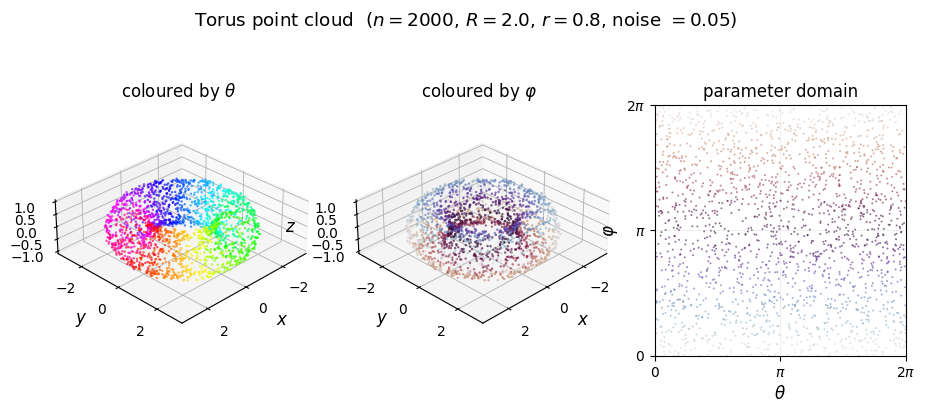

In [10]:
fig = plt.figure(figsize=(11, 4.2))

ax = fig.add_subplot(1, 3, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=THETA, cmap="hsv", s=3, alpha=0.7,
           edgecolors="none", rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(r"coloured by $\theta$")

ax = fig.add_subplot(1, 3, 2, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=PHI, cmap="twilight", s=3, alpha=0.7,
           edgecolors="none", rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(r"coloured by $\varphi$")

ax = fig.add_subplot(1, 3, 3)
ax.scatter(THETA, PHI, c=PHI, cmap="twilight", s=2, alpha=0.6, edgecolors="none",
           rasterized=True)
ax.set(xlabel=r"$\theta$", ylabel=r"$\varphi$", xlim=(0, TWO_PI), ylim=(0, TWO_PI))
ax.set_xticks([0, np.pi, TWO_PI]); ax.set_xticklabels(["$0$", r"$\pi$", r"$2\pi$"])
ax.set_yticks([0, np.pi, TWO_PI]); ax.set_yticklabels(["$0$", r"$\pi$", r"$2\pi$"])
ax.set_aspect("equal"); ax.set_title("parameter domain")

fig.suptitle(f"Torus point cloud  ($n={CFG.n_points}$, $R={CFG.R}$, "
             f"$r={CFG.r}$, noise $={CFG.noise}$)", y=1.02)
savefig(fig, "fig01_point_cloud")
plt.show()

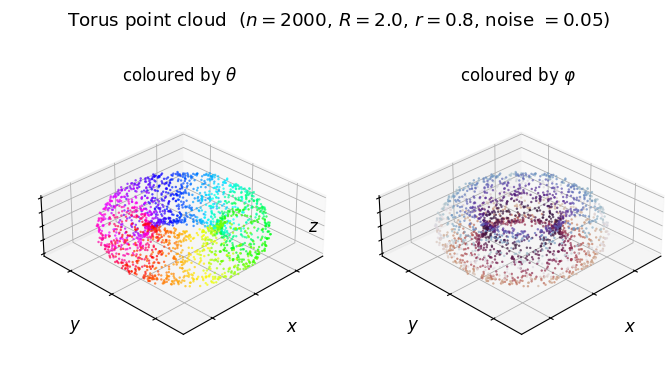

In [11]:
fig = plt.figure(figsize=(8, 4.2))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=THETA, cmap="hsv", s=3, alpha=0.7,
           edgecolors="none", rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
ax.set_title(r"coloured by $\theta$")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=PHI, cmap="twilight", s=3, alpha=0.7,
           edgecolors="none", rasterized=True)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
ax.set_title(r"coloured by $\varphi$")

fig.suptitle(f"Torus point cloud  ($n={CFG.n_points}$, $R={CFG.R}$, "
             f"$r={CFG.r}$, noise $={CFG.noise}$)", y=1.02)
savefig(fig, "fig01_point_cloud_paper")
plt.show()

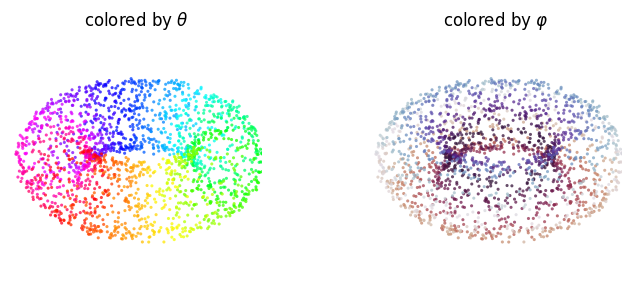

In [12]:
fig = plt.figure(figsize=(7.2, 2.8))

plot_settings = [
    (THETA, "hsv", r"colored by $\theta$"),
    (PHI, "twilight", r"colored by $\varphi$"),
]

# Manually fill almost the entire figure.
axis_positions = [
    [0.00, 0.00, 0.50, 0.90],
    [0.50, 0.00, 0.50, 0.90],
]

for position, (colour, cmap, title) in zip(
    axis_positions,
    plot_settings,
):
    ax = fig.add_axes(position, projection="3d")

    ax.scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        c=colour,
        cmap=cmap,
        s=5,
        alpha=0.75,
        edgecolors="none",
        rasterized=True,
    )

    # zoom enlarges the torus within each subplot.
    ax.set_box_aspect([1, 1, 0.35], zoom=1.45)
    ax.view_init(elev=30, azim=45)
    ax.margins(0)

    ax.set_axis_off()
    ax.set_facecolor("none")
    ax.set_title(title, pad=-4)

#fig.suptitle( rf"Torus point cloud " rf"($n={CFG.n_points}$, $R={CFG.R}$, "rf"$r={CFG.r}$, noise $={CFG.noise}$)", y=0.98, fontsize=12,)

savefig(fig, "fig01_point_cloud_paper")
plt.show()

In [13]:
MODES = {}
for t in sorted(set(CFG.t_figures) | {CFG.t_reference}):
    MODES[t] = frechet_modes(X, MU, t, CFG, verbose=True)

REFS, REF_INFO = select_reference_points(X, MU, CFG.t_reference,
                                         MODES[CFG.t_reference], CFG)
print(f"\nreference points fixed at t={CFG.t_reference}: {len(REFS)} points, "
      f"{REF_INFO['n_components']} component(s), {REF_INFO['n_voxels']} voxels, "
      f"band={REF_INFO['band']:.4g} of range {REF_INFO['span']:.4g}")

# How well do the reference points cover the surface?
d_surface = np.abs(np.hypot(np.hypot(REFS[:, 0], REFS[:, 1]) - CFG.R,
                            REFS[:, 2]) - CFG.r)
th_ref = np.arctan2(REFS[:, 1], REFS[:, 0]) % TWO_PI
print(f"  distance to torus surface: median {np.median(d_surface):.3f}, "
      f"max {d_surface.max():.3f}")
print(f"  theta occupancy (8 bins): {np.histogram(th_ref, 8, (0, TWO_PI))[0]}")

  t=0.01    46 seeds ->  40 distinct modes   drift: median=1.42e-01 max=4.78e-01
  t=0.5      1 seeds ->   1 distinct modes   drift: median=1.76e-01 max=1.76e-01
  t=2        1 seeds ->   1 distinct modes   drift: median=1.80e-01 max=1.80e-01
  t=2.25     1 seeds ->   1 distinct modes   drift: median=1.82e-01 max=1.82e-01
  t=2.5      1 seeds ->   1 distinct modes   drift: median=1.84e-01 max=1.84e-01
  t=2.75     1 seeds ->   1 distinct modes   drift: median=1.85e-01 max=1.85e-01
  t=3        1 seeds ->   1 distinct modes   drift: median=1.86e-01 max=1.86e-01
  t=3.25     1 seeds ->   1 distinct modes   drift: median=1.87e-01 max=1.87e-01
  t=3.5      1 seeds ->   1 distinct modes   drift: median=1.88e-01 max=1.88e-01
  t=3.75     1 seeds ->   1 distinct modes   drift: median=1.88e-01 max=1.88e-01
  t=4        1 seeds ->   1 distinct modes   drift: median=1.89e-01 max=1.89e-01
  t=5        1 seeds ->   1 distinct modes   drift: median=1.91e-01 max=1.91e-01

reference points fixed at t

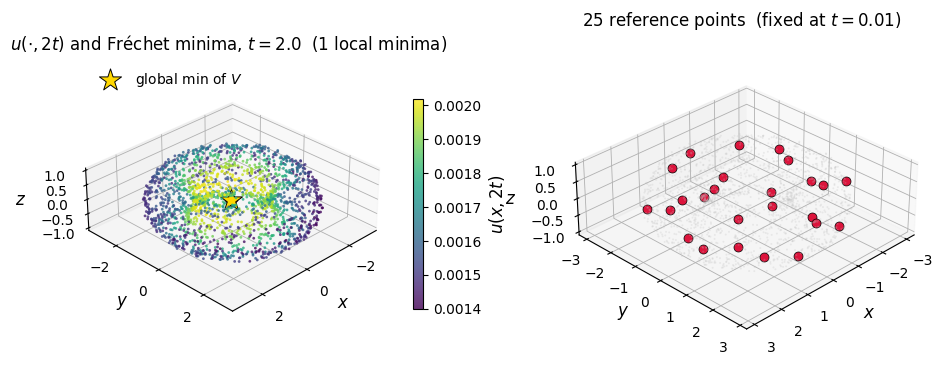

In [14]:
t_show = CFG.t_figures[1]
u_cloud = u_at(X, X, MU, 2 * t_show, CFG.chunk)

fig = plt.figure(figsize=(11, 4.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=u_cloud, cmap="viridis", s=4,
                alpha=0.8, edgecolors="none", rasterized=True)
for m in MODES[t_show]:
    ax.scatter(*m["x_star"], marker="D", s=45, c="crimson", edgecolors="k",
               linewidths=0.5, depthshade=False)
best = MODES[t_show][0]["x_star"]
ax.scatter(*best, marker="*", s=280, c="gold", edgecolors="k", linewidths=0.7,
           depthshade=False, label="global min of $V$")
fig.colorbar(sc, ax=ax, shrink=0.62, pad=0.10, label=r"$u(x,2t)$")
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.legend(loc="upper left")
ax.set_title(rf"$u(\cdot,2t)$ and Fréchet minima, $t={t_show}$"
             f"  ({len(MODES[t_show])} local minima)")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c="0.75", s=2, alpha=0.25,
           edgecolors="none", rasterized=True)
ax.scatter(REFS[:, 0], REFS[:, 1], REFS[:, 2], c="crimson", s=42,
           edgecolors="k", linewidths=0.5, depthshade=False)
ax.set(xlabel="$x$", ylabel="$y$", zlabel="$z$")
ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=30, azim=45)
ax.set_title(f"{len(REFS)} reference points  (fixed at $t={CFG.t_reference}$)")

savefig(fig, "fig02_frechet_and_reference_points")
plt.show()

## 7. RiePCA over the heat-time sweep


In [15]:
RIE, SPEC = {}, {}
for t in CFG.t_values:
    RIE[t] = riepca(REFS, X, MU, t, CFG)
    SPEC[t] = spectrum_table(RIE[t]["eigenvalues"], RIE[t]["trace"], CFG)

SCORES = np.stack([RIE[t]["scores"] for t in CFG.t_values], axis=-1)
print(f"scores {SCORES.shape}  (n_points, top_k, n_t)")

hdr = f"{'t':>7} {'trace(Q)':>12} {'cum(top10)':>11} {'sig PCs':>8}  degenerate pairs"
print("\n" + hdr + "\n" + "-" * len(hdr))
for t in CFG.t_values:
    s = SPEC[t]
    pairs = ", ".join(f"({k+1},{k+2})" for k in np.flatnonzero(s["degenerate"]))
    print(f"{t:>7g} {RIE[t]['trace']:>12.4e} {s['cumulative'][-1]*100:>10.2f}% "
          f"{s['significant'].sum():>8d}  {pairs}")

scores (2000, 10, 39)  (n_points, top_k, n_t)

      t     trace(Q)  cum(top10)  sig PCs  degenerate pairs
-----------------------------------------------------------
   0.01   5.2454e+02      34.67%       10  (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.1   6.9884e-01      33.35%       10  (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.2   9.3666e-02      47.95%       10  (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.3   2.9433e-02      58.99%       10  (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,10)
    0.5   6.4414e-03      76.28%       10  (1,2), (2,3), (3,4), (4,5), (6,7), (7,8), (9,10)
    0.7   2.2071e-03      85.63%       10  (1,2), (3,4), (4,5), (7,8), (8,9), (9,10)
    0.9   9.5111e-04      90.77%       10  (1,2), (3,4), (4,5), (7,8), (8,9), (9,10)
      1   6.6130e-04      92.48%       10  (1,2), (3,4), (4,5), (7,8), (8,9), (9,10)
    1.2   3.4769e-04      94.86%       10  (1,2), (4,5), (7,8), (8,9), (9,10

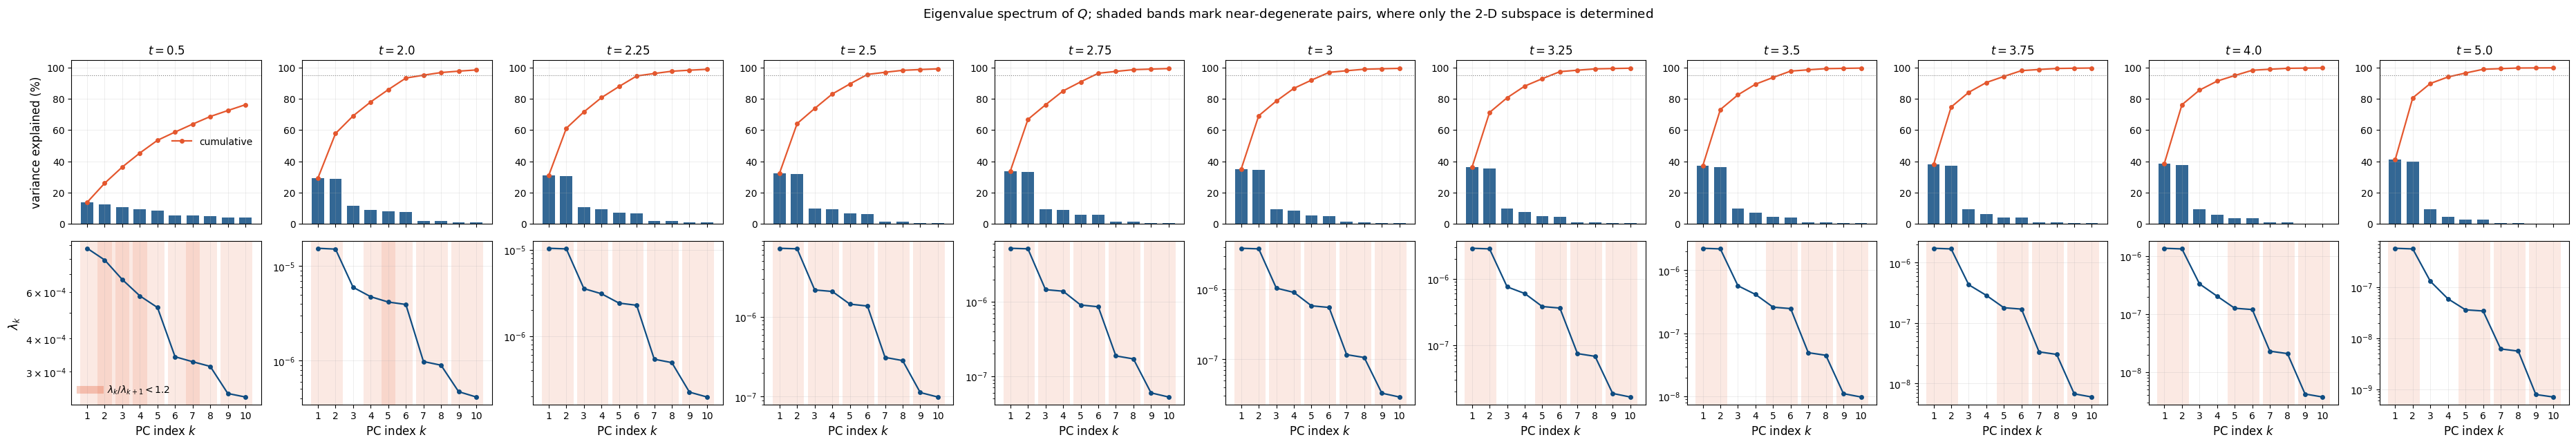

In [16]:
n = len(CFG.t_figures)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 6.4), sharex=True)

for j, t in enumerate(CFG.t_figures):
    s = SPEC[t]
    k = np.arange(1, len(s["share"]) + 1)

    ax = axes[0, j]
    ax.bar(k, s["share"] * 100, color="#0F4C81", alpha=0.85, width=0.7)
    ax.plot(k, s["cumulative"] * 100, "o-", color="#E4572E", ms=4,
            label="cumulative")
    ax.axhline(95, color="0.5", ls=":", lw=0.8)
    ax.set_ylim(0, 105); ax.set_xticks(k)
    ax.set_title(rf"$t={t}$")
    if j == 0:
        ax.set_ylabel("variance explained (%)")
        ax.legend(loc="center right")

    ax = axes[1, j]
    ax.semilogy(k, s["eigenvalues"], "o-", color="#0F4C81", ms=4)
    for kk in np.flatnonzero(s["degenerate"]):
        ax.axvspan(kk + 0.6, kk + 2.4, color="#E4572E", alpha=0.13, lw=0)
    ax.set_xticks(k); ax.set_xlabel("PC index $k$")
    if j == 0:
        ax.set_ylabel(r"$\lambda_k$")

axes[1, 0].plot([], [], color="#E4572E", alpha=0.3, lw=8,
                label=rf"$\lambda_k/\lambda_{{k+1}}<{CFG.degeneracy_ratio}$")
axes[1, 0].legend(loc="lower left")
fig.suptitle("Eigenvalue spectrum of $Q$; shaded bands mark near-degenerate "
             "pairs, where only the 2-D subspace is determined", y=1.00)
fig.tight_layout()
savefig(fig, "fig03_spectrum")
plt.show()

/tmp/ipykernel_2923/1899688124.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


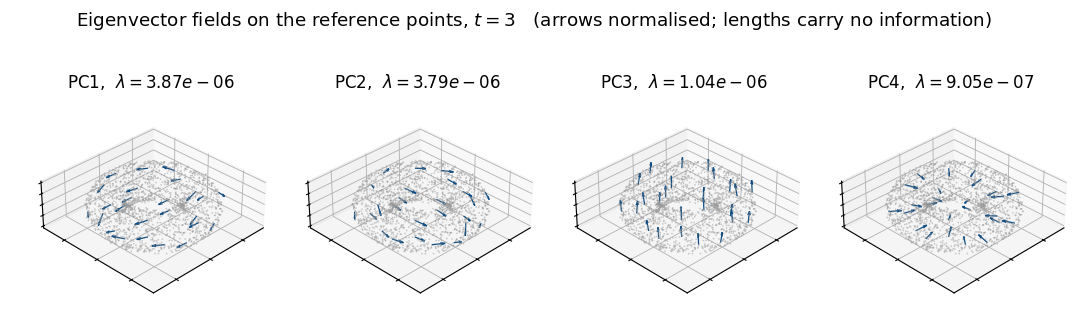

In [17]:
t_show = CFG.t_figures[5]
res = RIE[t_show]
n_show = 4
fig = plt.figure(figsize=(3.3 * n_show, 3.7))
for j in range(n_show):
    ax = fig.add_subplot(1, n_show, j + 1, projection="3d")
    F = res["fields"][j]
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c="0.6", s=1.5, alpha=0.5,
               edgecolors="none", rasterized=True)
    ax.quiver(REFS[:, 0], REFS[:, 1], REFS[:, 2], F[:, 0], F[:, 1], F[:, 2],
              length=0.55, normalize=True, color="#0F4C81", linewidth=0.9,
              arrow_length_ratio=0.35)
    ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=32, azim=45)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(rf"PC{j+1},  $\lambda={res['eigenvalues'][j]:.2e}$")
fig.suptitle(rf"Eigenvector fields on the reference points, $t={t_show}$"
             "   (arrows normalised; lengths carry no information)", y=1.03)
fig.tight_layout()
savefig(fig, "fig04_eigenvector_fields")
plt.show()

## 8. Score plots

`PC1`–`PC2` is the near-degenerate leading pair; a rotationally symmetric
torus should produce exactly that, and the pair is what carries the toroidal
angle $\theta$.

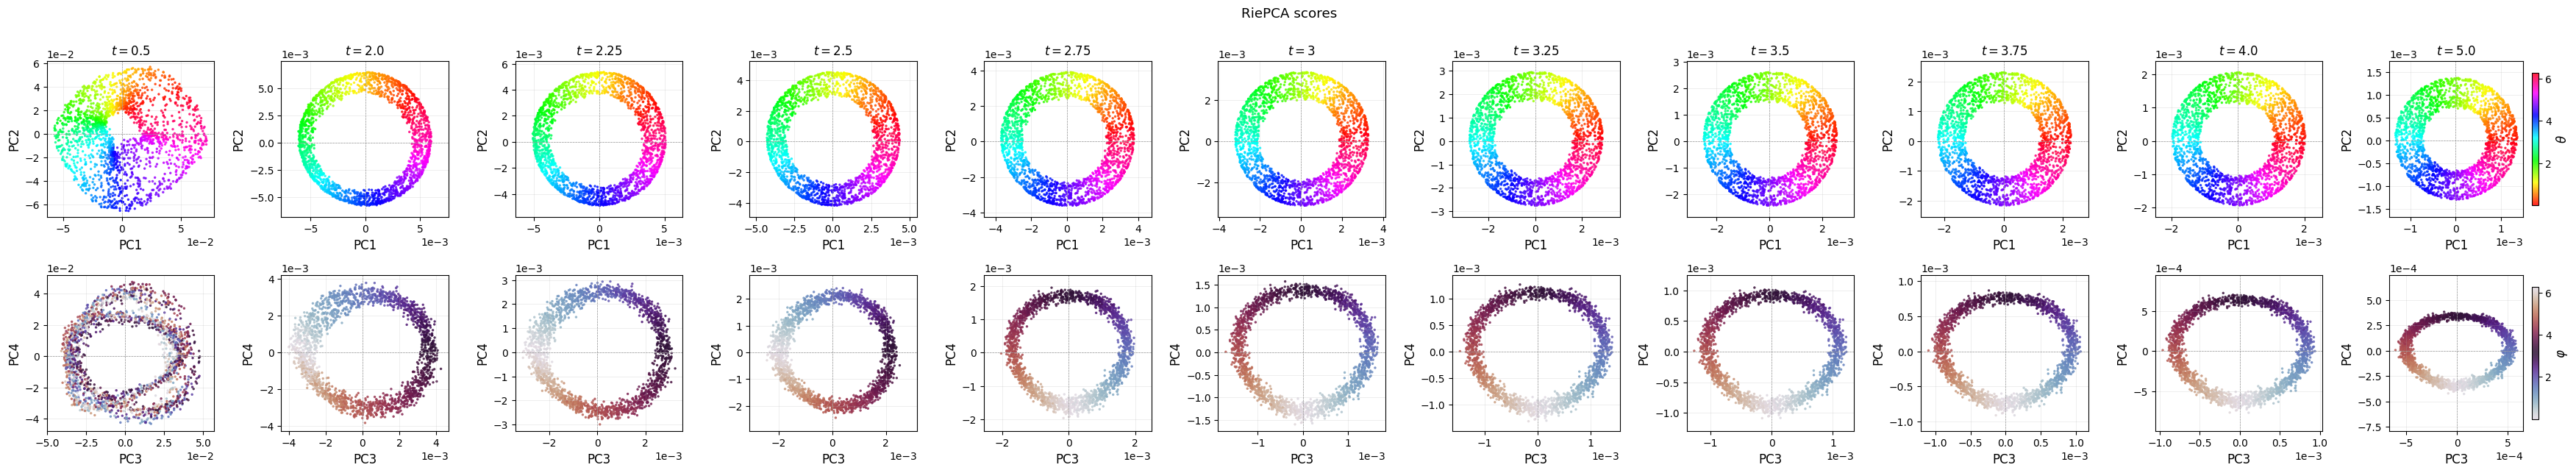

In [18]:
fig, axes = plt.subplots(2, len(CFG.t_figures),
                         figsize=(3.2 * len(CFG.t_figures), 6.4))
for j, t in enumerate(CFG.t_figures):
    ti = CFG.t_values.index(t)
    for row, (a, b, colour, cmap, lab) in enumerate([
            (0, 1, THETA, "hsv", r"$\theta$"),
            (2, 3, PHI, "twilight", r"$\varphi$")]):
        ax = axes[row, j]
        sc = ax.scatter(SCORES[:, a, ti], SCORES[:, b, ti], c=colour, cmap=cmap,
                        s=6, alpha=0.85, edgecolors="none", rasterized=True)
        ax.axhline(0, color="0.6", lw=0.5, ls="--")
        ax.axvline(0, color="0.6", lw=0.5, ls="--")
        ax.set_aspect("equal", adjustable="datalim")
        ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
        ax.set_xlabel(f"PC{a+1}"); ax.set_ylabel(f"PC{b+1}")
        if row == 0:
            ax.set_title(rf"$t={t}$")
        if j == len(CFG.t_figures) - 1:
            fig.colorbar(sc, ax=ax, shrink=0.85, label=lab)
fig.suptitle("RiePCA scores", y=1.00)
fig.tight_layout()
savefig(fig, "fig05_scores")
plt.show()

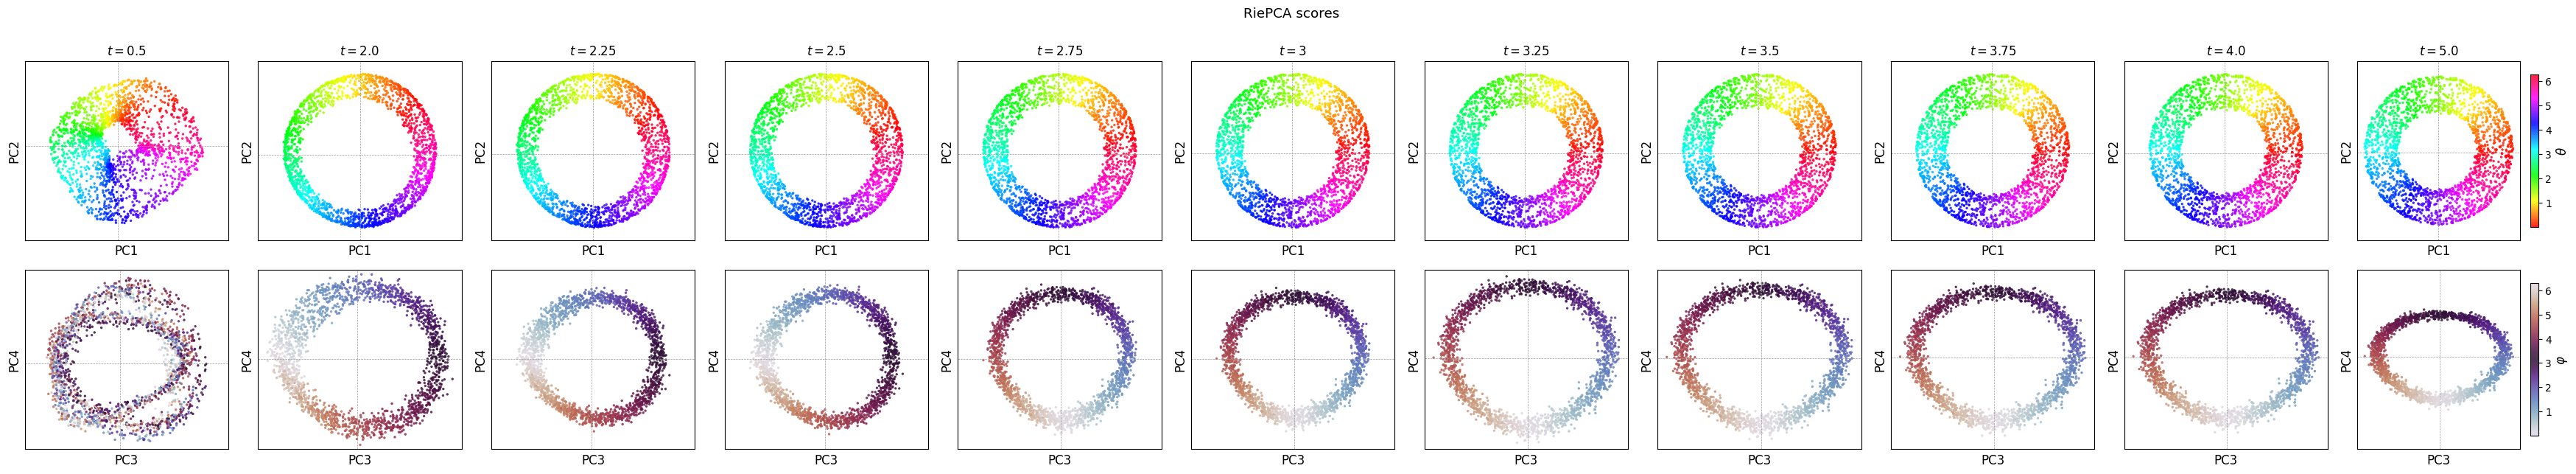

In [19]:
fig, axes = plt.subplots(2, len(CFG.t_figures),
                         figsize=(3.2 * len(CFG.t_figures), 6.4))
for j, t in enumerate(CFG.t_figures):
    ti = CFG.t_values.index(t)
    for row, (a, b, colour, cmap, lab) in enumerate([
            (0, 1, THETA, "hsv", r"$\theta$"),
            (2, 3, PHI, "twilight", r"$\varphi$")]):
        ax = axes[row, j]
        sc = ax.scatter(SCORES[:, a, ti], SCORES[:, b, ti], c=colour, cmap=cmap,
                        s=6, alpha=0.85, edgecolors="none", rasterized=True)
        ax.axhline(0, color="0.6", lw=0.5, ls="--")
        ax.axvline(0, color="0.6", lw=0.5, ls="--")
        ax.set_aspect("equal", adjustable="datalim")
        ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))
        # Remove tick marks and tick numbers
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(f"PC{a+1}"); ax.set_ylabel(f"PC{b+1}")
        if row == 0:
            ax.set_title(rf"$t={t}$")
        if j == len(CFG.t_figures) - 1:
            fig.colorbar(sc, ax=ax, shrink=0.85, label=lab)
fig.suptitle("RiePCA scores", y=1.00)
fig.tight_layout()
savefig(fig, "fig05_scores_no_colorbar")
plt.show()

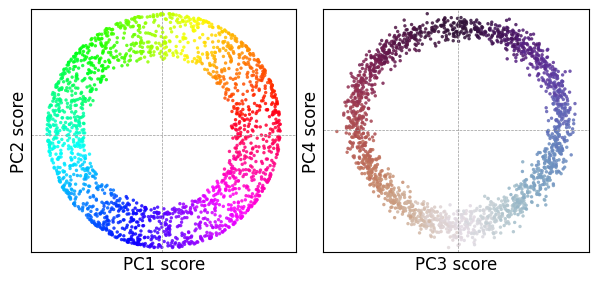

In [20]:
t_show = 2.75
ti = CFG.t_values.index(t_show)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(6, 3.2),
)

for ax, (a, b, colour, cmap) in zip(
    axes,
    [
        (0, 1, THETA, "hsv"),
        (2, 3, PHI, "twilight"),
    ],
):
    ax.scatter(
        SCORES[:, a, ti],
        SCORES[:, b, ti],
        c=colour,
        cmap=cmap,
        s=6,
        alpha=0.85,
        edgecolors="none",
        rasterized=True,
    )

    ax.axhline(0, color="0.6", lw=0.5, ls="--")
    ax.axvline(0, color="0.6", lw=0.5, ls="--")
    ax.set_aspect("equal", adjustable="datalim")
    ax.margins(0.02)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f"PC{a + 1} score", labelpad=2)
    ax.set_ylabel(f"PC{b + 1} score", labelpad=2)

#fig.suptitle(rf"RiePCA scores at $t={t_show:g}$", y=0.98)

# Reduce exterior margins and space between panels.
fig.subplots_adjust(
    left=0.065,
    right=0.995,
    bottom=0.12,
    top=0.88,
    wspace=0.10,
)

t_tag = f"{t_show:g}".replace(".", "p")
savefig(fig, f"fig05_scores_t_{t_tag}_same_row_no_colorbar")
plt.show()

/tmp/ipykernel_2923/1677881402.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


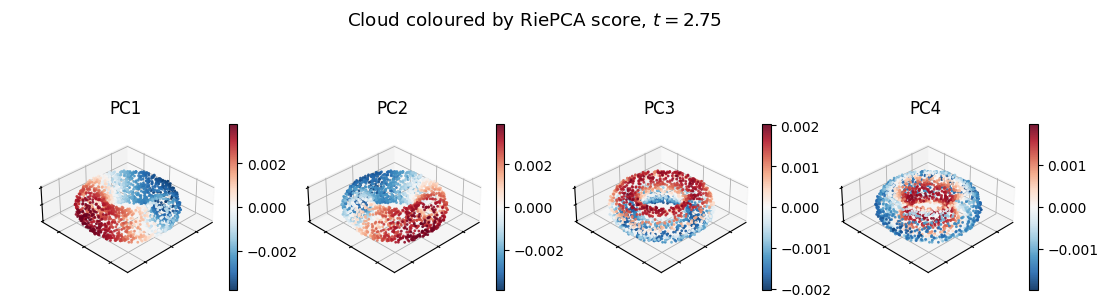

In [21]:
t_show = CFG.t_figures[4]
ti = CFG.t_values.index(t_show)
n_show = 4
fig = plt.figure(figsize=(3.3 * n_show, 3.7))
for j in range(n_show):
    v = SCORES[:, j, ti]
    lim = np.max(np.abs(v))
    norm = TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim) if lim > 0 else None
    ax = fig.add_subplot(1, n_show, j + 1, projection="3d")
    sc = ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=v, cmap="RdBu_r", norm=norm,
                    s=4, alpha=0.9, edgecolors="none", rasterized=True)
    fig.colorbar(sc, ax=ax, shrink=0.58, pad=0.08)
    ax.set_box_aspect([1, 1, 0.35]); ax.view_init(elev=32, azim=45)
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
    ax.set_title(f"PC{j+1}")
fig.suptitle(rf"Cloud coloured by RiePCA score, $t={t_show}$", y=1.03)
fig.tight_layout()
savefig(fig, "fig06_cloud_by_score")
plt.show()

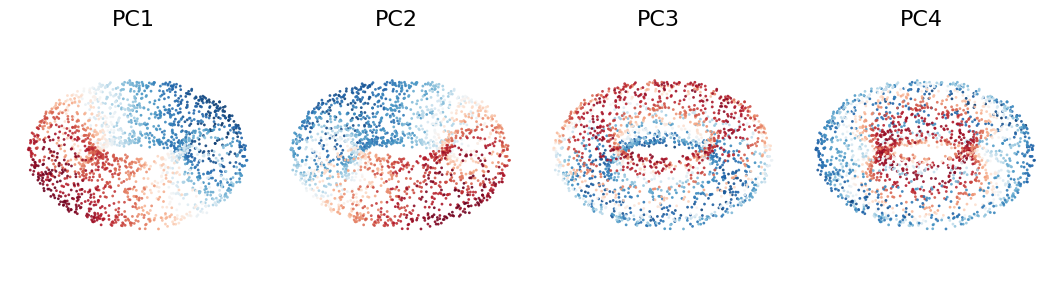

In [22]:
t_show = 2.75
ti = CFG.t_values.index(t_show)

n_show = 4
fig = plt.figure(figsize=(10.5, 2.75))

# Nearly edge-to-edge panel positions.
panel_width = 1.0 / n_show

for j in range(n_show):
    v = SCORES[:, j, ti]
    lim = np.max(np.abs(v))
    norm = (
        TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim)
        if lim > 0 else None
    )

    ax = fig.add_axes(
        [j * panel_width, 0.00, panel_width, 0.90],
        projection="3d",
    )

    ax.scatter(
        X[:, 0],
        X[:, 1],
        X[:, 2],
        c=v,
        cmap="RdBu_r",
        norm=norm,
        s=4,
        alpha=0.9,
        edgecolors="none",
        rasterized=True,
    )

    ax.set_axis_off()
    ax.set_facecolor("none")
    ax.set_box_aspect([1, 1, 0.35], zoom=1.3)
    ax.view_init(elev=32, azim=45)
    ax.margins(0)
    ax.set_title(f"PC{j + 1}", pad=-8,fontsize=16)


savefig(fig, "fig06_cloud_by_score_no_color_bar")
plt.show()

## 9. Does the PC3–PC4 plane carry the meridional circle?

This is the claim the original notebook set out to check, and the honest answer
is **conditionally yes, globally no**.

Pooled over the whole cloud, the polar angle of the PC3–PC4 scatter has
circular correlation $\approx 0.15$ with $\varphi$ — essentially none. Restricted
to a fixed $\theta$ slice it rises to $0.5$–$0.98$. The PC3–PC4 plane carries a
$\theta$-dependent frame, so the meridional circle is recovered *within* a
slice but is smeared into an annulus once slices are superposed.

The per-slice quality is uneven (high at $\theta\approx 0, 2.4, 4.7$, poor at
$\theta\approx 1.6, 3.9, 5.5$), which tracks the irregular $\theta$ occupancy of
the 25 KMeans reference points rather than anything about the torus.

The slice masks use `angular_mask`; with the naive `|theta - c| < tol` the
$\theta\approx 0$ panel — the first one a reader looks at — silently showed
only half of its circle.

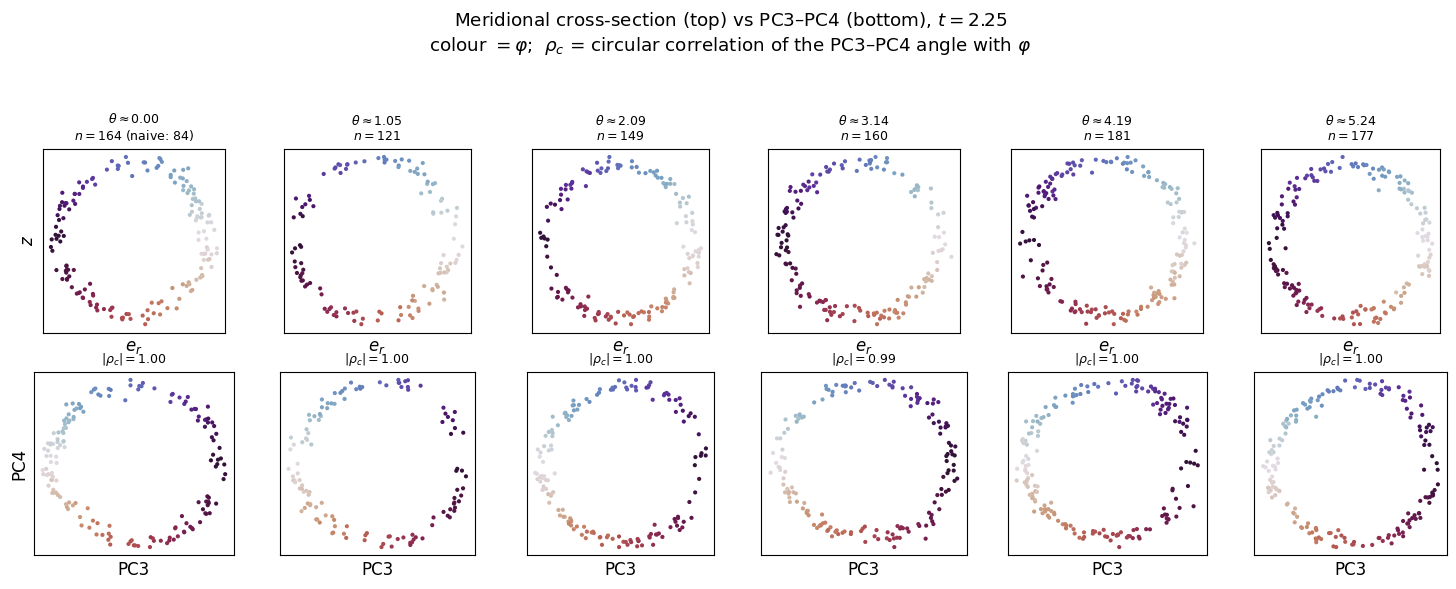

   theta  n (wrapped)  n (naive)   |rho_c|
   0.000          164         84     0.997
   1.047          121        121     0.997
   2.094          149        149     0.997
   3.142          160        160     0.988
   4.189          181        181     0.996
   5.236          177        177     0.996

mean |rho_c| over slices: 0.995


In [23]:
t_show = CFG.t_figures[2]
ti = CFG.t_values.index(t_show)
slice_centres = np.linspace(0, TWO_PI, 6, endpoint=False)
TOL = 0.25

fig, axes = plt.subplots(2, len(slice_centres),
                         figsize=(2.5 * len(slice_centres), 5.4))
rows = []
for j, tv in enumerate(slice_centres):
    m = angular_mask(THETA, tv, TOL)
    naive = (np.abs(THETA - tv) < TOL).sum()

    e_r = np.array([np.cos(tv), np.sin(tv), 0.0])
    ax = axes[0, j]
    ax.scatter(X[m] @ e_r, X[m, 2], c=PHI[m], cmap="twilight", s=9,
               vmin=0, vmax=TWO_PI, edgecolors="none")
    ax.set_aspect("equal")
    # Remove tick marks and tick numbers
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(rf"$\theta\approx{tv:.2f}$" "\n" rf"$n={m.sum()}$"
                 + (rf" (naive: {naive})" if naive != m.sum() else ""),
                 fontsize=9)
    if j == 0:
        ax.set_ylabel("$z$")
    ax.set_xlabel(r"$e_r$")

    p3, p4 = SCORES[m, 2, ti], SCORES[m, 3, ti]
    ang = np.arctan2(p4 - p4.mean(), p3 - p3.mean())
    rho = circ_assoc(ang, PHI[m])
    rows.append((tv, m.sum(), naive, rho))

    ax = axes[1, j]
    ax.scatter(p3, p4, c=PHI[m], cmap="twilight", s=9, vmin=0, vmax=TWO_PI,
               edgecolors="none")
    ax.set_aspect("equal"); ax.ticklabel_format(style="sci", axis="both",
                                                scilimits=(0, 0))
    ax.set_title(rf"$|\rho_c|={rho:.2f}$", fontsize=9)
    # Remove tick marks and tick numbers
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("PC3")
    if j == 0:
        ax.set_ylabel("PC4")

fig.suptitle(rf"Meridional cross-section (top) vs PC3–PC4 (bottom), $t={t_show}$"
             "\n" r"colour $=\varphi$;  $\rho_c$ = circular correlation of the "
             r"PC3–PC4 angle with $\varphi$", y=1.06)
fig.tight_layout()
savefig(fig, "fig07_meridional_slices")
plt.show()

print(f"{'theta':>8} {'n (wrapped)':>12} {'n (naive)':>10} {'|rho_c|':>9}")
for tv, nw, nn, rho in rows:
    print(f"{tv:>8.3f} {nw:>12d} {nn:>10d} {rho:>9.3f}")
print(f"\nmean |rho_c| over slices: {np.mean([r[3] for r in rows]):.3f}")

In [24]:
print(f"{'t':>7} {'rho(PC1-PC2 angle, theta)':>27} {'rho(PC3-PC4 angle, phi)':>25}"
      f" {'per-slice mean':>15}")
for t in CFG.t_figures + (2.0, 20.0):
    ti = CFG.t_values.index(t)
    a12 = np.arctan2(SCORES[:, 1, ti] - SCORES[:, 1, ti].mean(),
                     SCORES[:, 0, ti] - SCORES[:, 0, ti].mean())
    a34 = np.arctan2(SCORES[:, 3, ti] - SCORES[:, 3, ti].mean(),
                     SCORES[:, 2, ti] - SCORES[:, 2, ti].mean())
    per = []
    for tv in np.linspace(0, TWO_PI, 8, endpoint=False):
        m = angular_mask(THETA, tv, 0.25)
        a = np.arctan2(SCORES[m, 3, ti] - SCORES[m, 3, ti].mean(),
                       SCORES[m, 2, ti] - SCORES[m, 2, ti].mean())
        per.append(circ_assoc(a, PHI[m]))
    print(f"{t:>7g} {circ_assoc(a12, THETA):>27.5f}"
          f" {circ_assoc(a34, PHI):>25.5f} {np.mean(per):>15.5f}")

      t   rho(PC1-PC2 angle, theta)   rho(PC3-PC4 angle, phi)  per-slice mean
    0.5                     0.97103                   0.06472         0.30689
      2                     0.99891                   0.99061         0.99159
   2.25                     0.99899                   0.99382         0.99290
    2.5                     0.99904                   0.99493         0.99354
   2.75                     0.99907                   0.99535         0.99377
      3                     0.99910                   0.99533         0.99366
   3.25                     0.99912                   0.99495         0.99325
    3.5                     0.99913                   0.99428         0.99257
   3.75                     0.99914                   0.99337         0.99166
      4                     0.99915                   0.99224         0.99055
      5                     0.99917                   0.98612         0.98453
      2                     0.99891                   0.99061   

## 10. Baselines: Euclidean PCA and kernel PCA

Euclidean PCA explained variance: [0.4743 0.457  0.0687]
kernel PCA (sigma=4) eigenvalue share: [0.4149 0.4001 0.0648 0.0345 0.0326 0.0287]


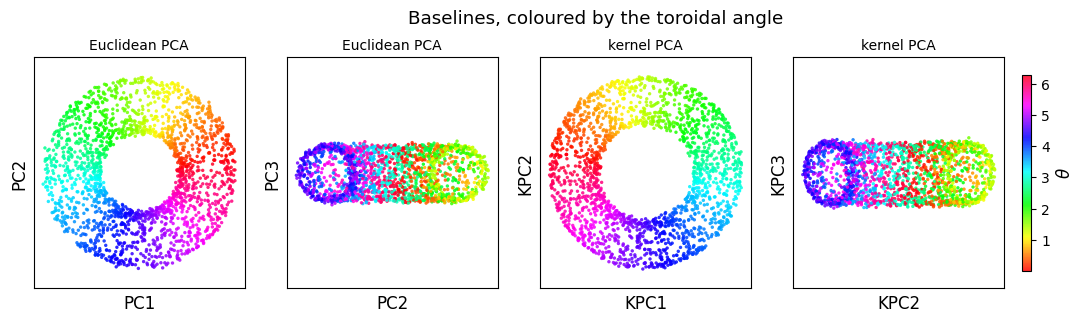

In [25]:
def pca_euclidean(A, n_components=3):
    A = np.asarray(A, float)
    mean = A.mean(0, keepdims=True)
    Ac = A - mean
    _, S, Vt = np.linalg.svd(Ac, full_matrices=False)
    ev = S ** 2 / max(len(A) - 1, 1)
    return Ac @ Vt[:n_components].T, ev / ev.sum(), Vt[:n_components], mean.ravel()


def kernel_pca_rbf(A, sigma, n_components=6):
    """Centred RBF kernel PCA. Scores are sqrt(lambda) * alpha, so the
    1/sqrt(lambda) normalisation cannot blow up on near-null components."""
    A = np.asarray(A, float)
    n = len(A)
    d2 = np.maximum(pairwise_distances(A) ** 2, 0.0)
    K = np.exp(-d2 / (2.0 * sigma ** 2))
    H = np.eye(n) - 1.0 / n
    Kc = H @ K @ H
    w, Vv = np.linalg.eigh(0.5 * (Kc + Kc.T))
    order = np.argsort(w)[::-1]
    w, Vv = np.maximum(w[order], 0.0), _pin_signs(Vv[:, order])
    k = n_components
    return Vv[:, :k] * np.sqrt(w[:k]), w[:k] / w.sum()


Y_PCA, EVR_PCA, _, _ = pca_euclidean(X, 3)
Y_KPCA, EVR_KPCA = kernel_pca_rbf(X, sigma=4.0, n_components=6)
print("Euclidean PCA explained variance:", np.round(EVR_PCA[:3], 4))
print("kernel PCA (sigma=4) eigenvalue share:", np.round(EVR_KPCA, 4))

panels = [("Euclidean PCA", Y_PCA[:, 0], Y_PCA[:, 1], "PC1", "PC2"),
          ("Euclidean PCA", Y_PCA[:, 1], Y_PCA[:, 2], "PC2", "PC3"),
          ("kernel PCA", Y_KPCA[:, 0], Y_KPCA[:, 1], "KPC1", "KPC2"),
          ("kernel PCA", Y_KPCA[:, 1], Y_KPCA[:, 2], "KPC2", "KPC3")]

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, (name, a, b, la, lb) in zip(axes, panels):
    sc = ax.scatter(a, b, c=THETA, cmap="hsv", s=6, alpha=0.85,
                    edgecolors="none", rasterized=True)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel(la); ax.set_ylabel(lb); ax.set_title(name, fontsize=10)
    # Remove tick marks and tick numbers
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(sc, ax=axes, shrink=0.85, label=r"$\theta$", pad=0.015)
fig.suptitle("Baselines, coloured by the toroidal angle", y=1.04)
savefig(fig, "fig08_baselines")
plt.show()